In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [32]:
data=pd.read_csv("lms_student_dataset.csv")

In [33]:
data.head()

,student_id,course_id,attendance_rate,avg_session_duration_pct,consecutive_absences,assignment_submission_rate,avg_assignment_score,late_submission_count,exam_score_avg,exam_improvement_trend,at_risk,pass_fail,predicted_grade
0,s_1000,c_1,0.738,0.540,2,0.832,71.19,2,71.17,0.0376,0,1,B
1,s_1001,c_1,0.653,0.604,2,0.403,46.39,4,16.62,-0.0996,1,0,F
2,s_1002,c_3,0.701,0.682,1,0.816,72.92,0,76.92,-0.1500,0,1,B
3,s_1003,c_1,0.634,1.000,2,0.497,77.98,1,76.67,0.0291,0,0,B
4,s_1004,c_3,0.910,1.000,0,0.917,87.97,0,74.06,0.0207,0,1,A


In [34]:
data.shape

(1000, 13)

# Exploratory Data Analysis

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   object 
 1   course_id                   1000 non-null   object 
 2   attendance_rate             1000 non-null   float64
 3   avg_session_duration_pct    1000 non-null   float64
 4   consecutive_absences        1000 non-null   int64  
 5   assignment_submission_rate  1000 non-null   float64
 6   avg_assignment_score        1000 non-null   float64
 7   late_submission_count       1000 non-null   int64  
 8   exam_score_avg              1000 non-null   float64
 9   exam_improvement_trend      1000 non-null   float64
 10  at_risk                     1000 non-null   int64  
 11  pass_fail                   1000 non-null   int64  
 12  predicted_grade             1000 non-null   object 
dtypes: float64(6), int64(4), object(3)

In [36]:
data.describe()

,attendance_rate,avg_session_duration_pct,consecutive_absences,assignment_submission_rate,avg_assignment_score,late_submission_count,exam_score_avg,exam_improvement_trend,at_risk,pass_fail
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.728097,0.708812,1.169000,0.749405,65.590140,1.504000,62.769200,0.016052,0.246000,0.721000
std,0.178155,0.182630,1.387214,0.176658,14.999396,1.645811,15.841781,0.073222,0.430894,0.448732
min,0.100000,0.100000,0.000000,0.100000,16.320000,0.000000,10.000000,-0.278300,0.000000,0.000000
25%,0.633750,0.600750,0.000000,0.662750,56.172500,0.000000,53.592500,-0.028350,0.000000,0.000000
50%,0.745500,0.730500,1.000000,0.776000,65.745000,1.000000,64.395000,0.021100,0.000000,1.000000
75%,0.861000,0.848250,2.000000,0.885500,76.760000,2.000000,74.145000,0.067450,0.000000,1.000000
max,1.000000,1.000000,6.000000,1.000000,100.000000,7.000000,97.940000,0.217800,1.000000,1.000000


In [37]:
data.isnull().sum()

student_id                    0
course_id                     0
attendance_rate               0
avg_session_duration_pct      0
consecutive_absences          0
assignment_submission_rate    0
avg_assignment_score          0
late_submission_count         0
exam_score_avg                0
exam_improvement_trend        0
at_risk                       0
pass_fail                     0
predicted_grade               0
dtype: int64

In [38]:
duplicate_rows_data=data[data.duplicated()]
print ("duplicated rows :" ,duplicate_rows_data.shape)

duplicated rows : (0, 13)


# Visualize label balance

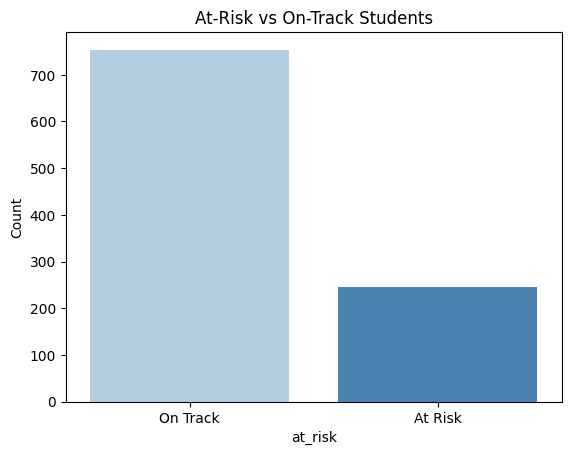

In [39]:
sns.countplot(x='at_risk', data=data, palette='Blues')
plt.title('At-Risk vs On-Track Students')
plt.xticks([0, 1], ['On Track', 'At Risk'])
plt.ylabel('Count')
plt.show()

#  Correlation heatmap 

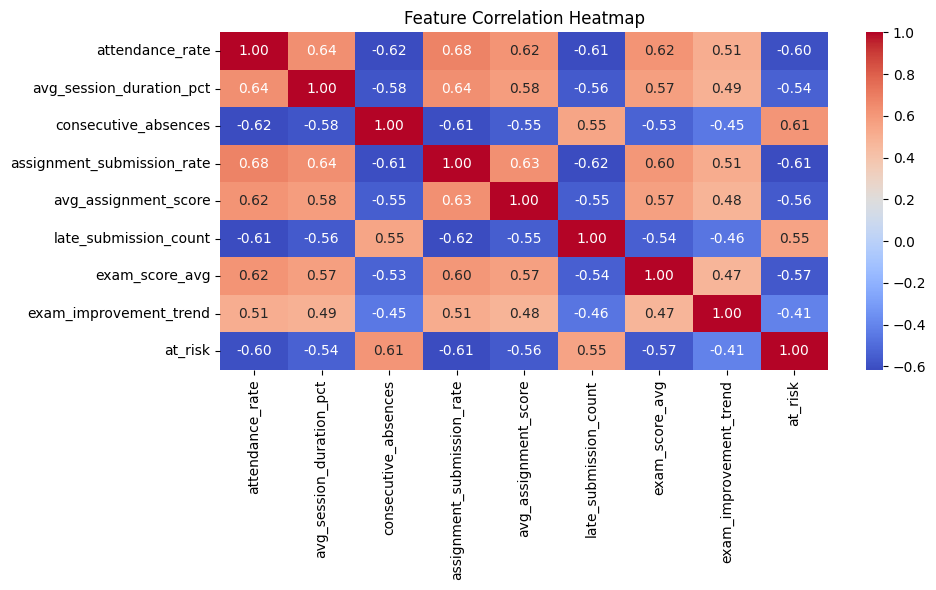

In [40]:
features = ['attendance_rate', 'avg_session_duration_pct', 'consecutive_absences',
            'assignment_submission_rate', 'avg_assignment_score',
            'late_submission_count', 'exam_score_avg', 'exam_improvement_trend']

plt.figure(figsize=(10, 6))
sns.heatmap(data[features + ['at_risk']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Prepare features and labels

In [41]:
X = data[features]
y = data['at_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 800
Test samples     : 200


# Scale features

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train model

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []

for name, model in models.items():
    # Logistic Regression needs scaled data, others don't
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results.append({'Model': name, 'Accuracy': round(acc,4), 'ROC-AUC': round(auc,4)})
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['On Track', 'At Risk']))

# Summary table
print("\n=== MODEL COMPARISON ===")
print(pd.DataFrame(results).to_string(index=False))


=== Logistic Regression ===
              precision    recall  f1-score   support

    On Track       0.92      0.98      0.95       151
     At Risk       0.92      0.73      0.82        49

    accuracy                           0.92       200
   macro avg       0.92      0.86      0.88       200
weighted avg       0.92      0.92      0.92       200


=== Random Forest ===
              precision    recall  f1-score   support

    On Track       0.94      0.98      0.96       151
     At Risk       0.93      0.80      0.86        49

    accuracy                           0.94       200
   macro avg       0.93      0.89      0.91       200
weighted avg       0.93      0.94      0.93       200


=== XGBoost ===
              precision    recall  f1-score   support

    On Track       0.94      0.95      0.94       151
     At Risk       0.83      0.82      0.82        49

    accuracy                           0.92       200
   macro avg       0.89      0.88      0.88       200
weigh

In [44]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Confusion matrices

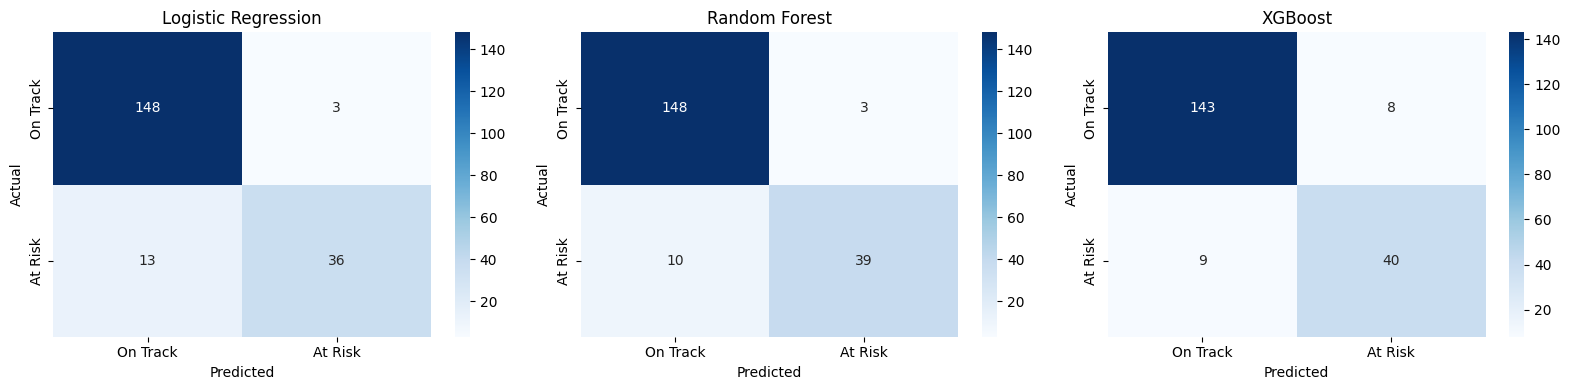

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

trained_models = [
    ('Logistic Regression', models['Logistic Regression'], X_test_scaled),
    ('Random Forest',       models['Random Forest'],       X_test),
    ('XGBoost',             models['XGBoost'],             X_test)
]

for ax, (title, model, X_eval) in zip(axes, trained_models):
    preds = model.predict(X_eval)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['On Track', 'At Risk'],
                yticklabels=['On Track', 'At Risk'])
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# ROC Curve comparsion

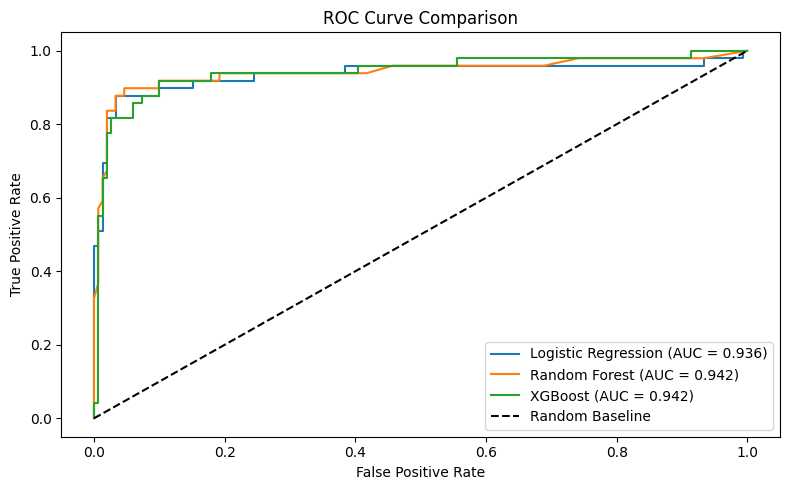

In [47]:
plt.figure(figsize=(8, 5))

trained_models = [
    ('Logistic Regression', models['Logistic Regression'], X_test_scaled),
    ('Random Forest',       models['Random Forest'],       X_test),
    ('XGBoost',             models['XGBoost'],             X_test)
]

for title, model, X_eval in trained_models:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_eval)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_eval)[:,1])
    plt.plot(fpr, tpr, label=f'{title} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance 

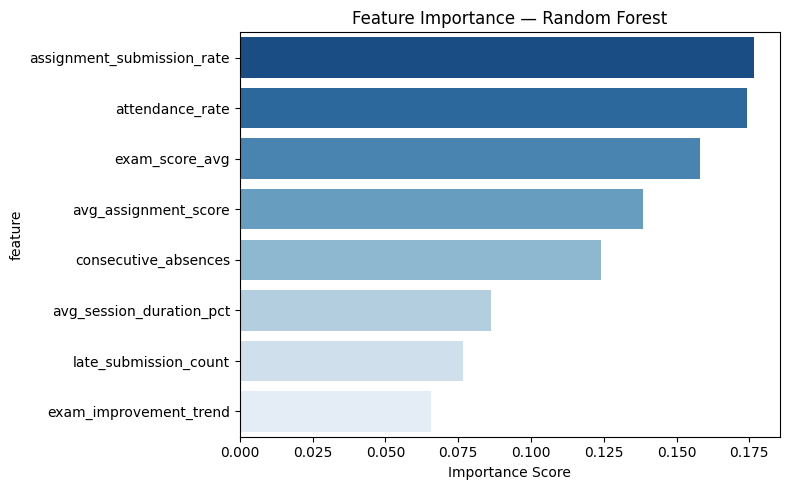

                   feature  importance
assignment_submission_rate    0.176697
           attendance_rate    0.174114
            exam_score_avg    0.157919
      avg_assignment_score    0.138421
      consecutive_absences    0.123964
  avg_session_duration_pct    0.086412
     late_submission_count    0.076639
    exam_improvement_trend    0.065832


In [49]:
rf_model = models['Random Forest']

importance_df = pd.DataFrame({
    'feature'   : features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=importance_df, palette='Blues_r')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

# predict a single student

In [54]:
new_student = pd.DataFrame([{
    'attendance_rate'           : 0.45,
    'avg_session_duration_pct'  : 0.50,
    'consecutive_absences'      : 3,
    'assignment_submission_rate': 0.55,
    'avg_assignment_score'      : 48.0,
    'late_submission_count'     : 4,
    'exam_score_avg'            : 42.0,
    'exam_improvement_trend'    : -0.08
}])

for title, model, X_eval in [
    ('Logistic Regression', models['Logistic Regression'], scaler.transform(new_student)),
    ('Random Forest',       models['Random Forest'],       new_student),
    ('XGBoost',             models['XGBoost'],             new_student)
]:
    prob  = model.predict_proba(X_eval)[0][1]
    label = model.predict(X_eval)[0]
    print(f"{title:25s} → Risk: {prob:.2%}  |  {'AT RISK ' if label == 1 else 'ON TRACK'}")

Logistic Regression       → Risk: 94.71%  |  AT RISK 
Random Forest             → Risk: 98.00%  |  AT RISK 
XGBoost                   → Risk: 99.95%  |  AT RISK 


In [57]:
import joblib

# Save the model
joblib.dump(models['Random Forest'], 'lms_risk_model.pkl')

# Load it later in your FastAPI
model = joblib.load('lms_risk_model.pkl')

print("Model saved and loaded successfully!")
print(f"Model type: {type(model)}")

Model saved and loaded successfully!
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
